# Stage 4 — Bistatic P(detect) Heat-Map (N=2560, 5,000 solves)

Full MC sweep across 5 targets × 4 roughness levels × 5 wavenumbers × 50 seeds.

Fixed nose-on incidence (d = [1, 0, 0], θ=90°, φ=0°).
Observation: full 18×36 sphere grid (648 directions).

**Key questions:**
- Where on the observation sphere is each target detectable from nose-on?
- How much does roughness raise detection probability?
- Does the 3D stealth body replicate the 2D "stealth paradox" (flanking detection)?


In [1]:
import sys, os, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

_HERE = Path(os.getcwd())
sys.path.insert(0, str(_HERE))
sys.path.insert(0, str(_HERE / '..' / 'bem_cobol'))

import generate_stage4_data_3d as g4
from generate_stage4_data_3d import (TARGETS, ROUGHNESS_FRACS, WAVENUMBERS,
                                      N_PANELS, N_SEEDS, THRESHOLD_DBSM,
                                      DATA_ROOT, count_existing, load_group)
from rcs_3d import obs_grid

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

_, OBS_THETA, OBS_PHI = obs_grid(18, 36)
total_groups = len(TARGETS) * len(ROUGHNESS_FRACS) * len(WAVENUMBERS)
existing     = count_existing()

print(f"Stage 4 config: {len(TARGETS)} targets × {len(ROUGHNESS_FRACS)} roughness × "
      f"{len(WAVENUMBERS)} freq × {N_SEEDS} seeds = {total_groups} groups × {N_SEEDS} solves")
print(f"N={N_PANELS}  threshold={THRESHOLD_DBSM} dBsm")
print(f"Existing: {existing}/{total_groups} groups")


Stage 4 config: 5 targets × 4 roughness × 5 freq × 50 seeds = 100 groups × 50 solves
N=2560  threshold=-10.0 dBsm
Existing: 100/100 groups


## 1. Generate data (runs ~1–3 min; skips existing groups)

In [2]:
if existing < total_groups:
    print(f"Generating {total_groups - existing} groups...")
    g4.generate_all(verbose=True)
else:
    print("All groups present — skipping generation.")


All groups present — skipping generation.


## 2. P(detect) summary heat-map — target × roughness at k=8

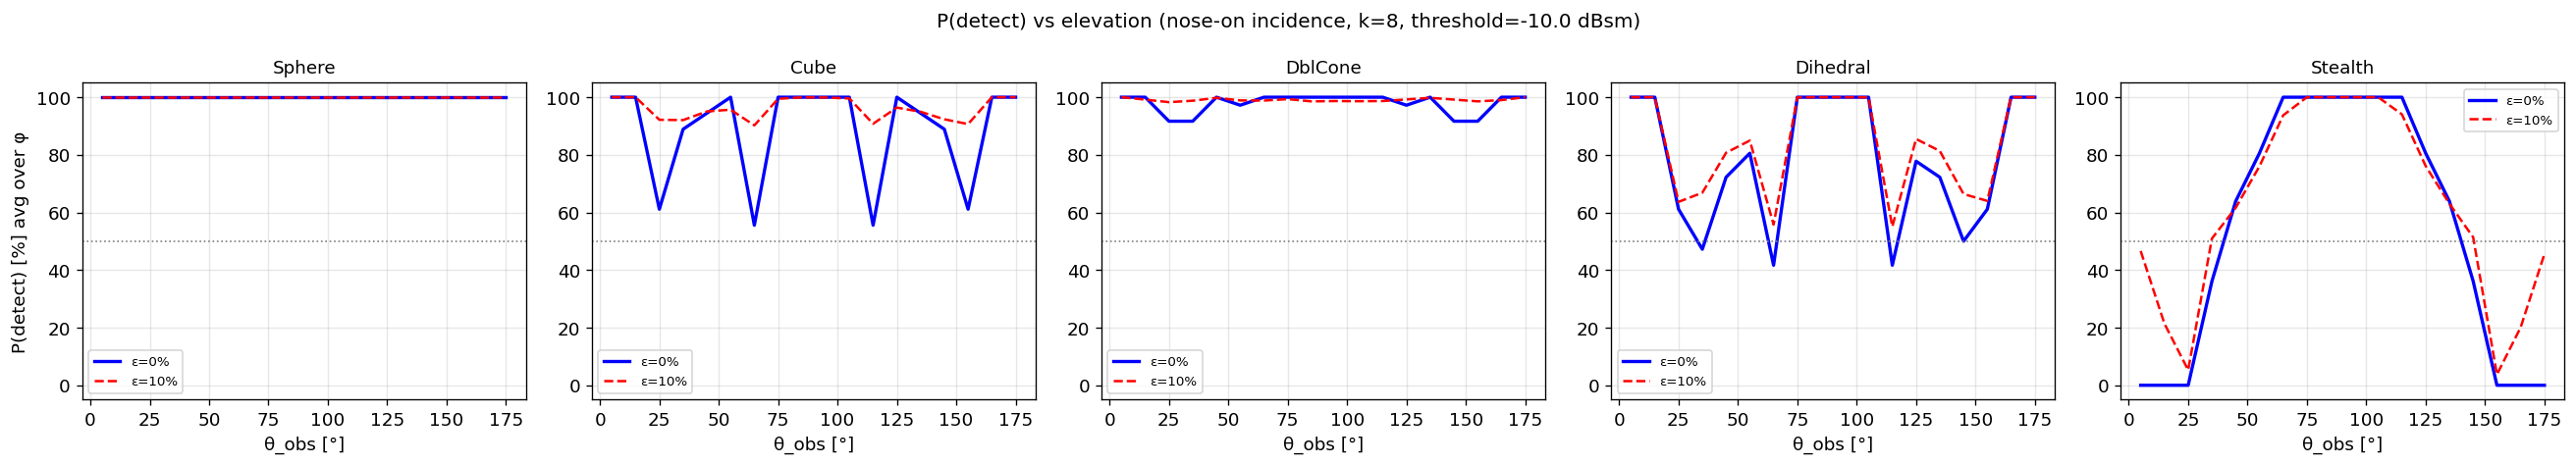

In [3]:
f_idx = 2   # k=8
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for col, tgt in enumerate(TARGETS):
    ax = axes[col]
    pdet_vals = []
    eps_labels = []
    for r_idx, eps in enumerate(ROUGHNESS_FRACS):
        d = load_group(tgt['id'], r_idx, f_idx)
        if d is None:
            pdet_vals.append(np.zeros((18, 36)))
        else:
            pdet_vals.append(d['p_detect'])
        eps_labels.append(f'ε={eps:.0%}')

    # Stack into (4, 18, 36) and show P(detect) sphere map for ε=0 and ε=10%
    for r_idx, (pdet, label) in enumerate(zip(pdet_vals, eps_labels)):
        if r_idx in [0, 2]:  # smooth and ε=10%
            lw  = 2.0 if r_idx == 0 else 1.5
            ls  = '-' if r_idx == 0 else '--'
            col_line = 'blue' if r_idx == 0 else 'red'
            # Mean over phi for 1D cut
            ax.plot(np.rad2deg(OBS_THETA), pdet.mean(axis=1) * 100,
                    color=col_line, lw=lw, ls=ls, label=label)

    ax.axhline(50, color='gray', ls=':', lw=1)
    ax.set_title(tgt['name'], fontsize=11)
    ax.set_xlabel('θ_obs [°]'); ax.set_ylim(-5, 105)
    if col == 0:
        ax.set_ylabel('P(detect) [%] avg over φ')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle(f'P(detect) vs elevation (nose-on incidence, k={WAVENUMBERS[f_idx]:.0f}, '
             f'threshold={THRESHOLD_DBSM} dBsm)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_stage4_3d_pdet_elevation.png', dpi=120, bbox_inches='tight')
plt.show()


## 3. Full bistatic P(detect) sphere — stealth body at k=8, ε=0 vs ε=10%

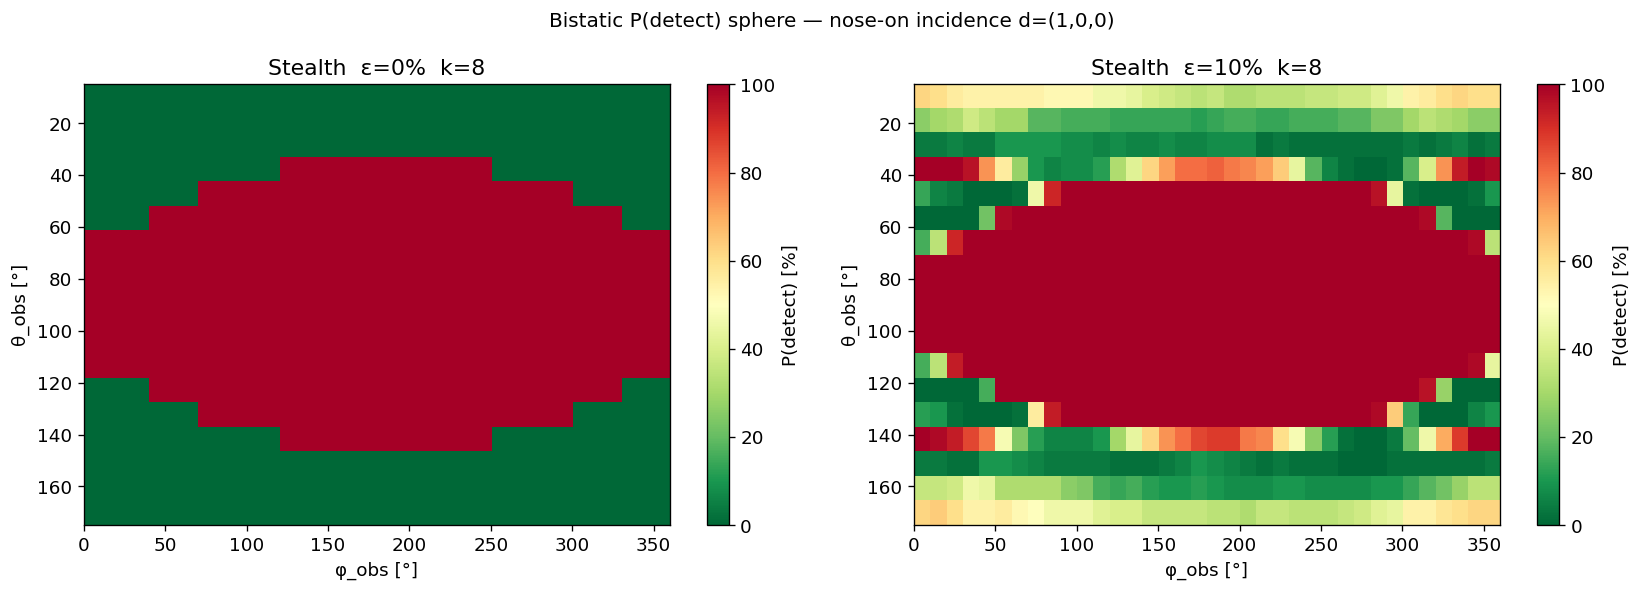

In [4]:
f_idx = 2   # k=8
t_idx = 4   # stealth
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, r_idx in zip(axes, [0, 2]):
    eps   = ROUGHNESS_FRACS[r_idx]
    d     = load_group(t_idx, r_idx, f_idx)
    pdet  = d['p_detect'] if d is not None else np.zeros((18, 36))

    im = ax.imshow(pdet * 100, origin='upper', aspect='auto',
                   vmin=0, vmax=100, cmap='RdYlGn_r',
                   extent=[0, 360, np.rad2deg(OBS_THETA[-1]),
                            np.rad2deg(OBS_THETA[0])])
    ax.set_title(f'Stealth  ε={eps:.0%}  k={WAVENUMBERS[f_idx]:.0f}')
    ax.set_xlabel('φ_obs [°]'); ax.set_ylabel('θ_obs [°]')
    plt.colorbar(im, ax=ax, label='P(detect) [%]')

fig.suptitle('Bistatic P(detect) sphere — nose-on incidence d=(1,0,0)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_stage4_3d_stealth_pdet_sphere.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Roughness effect — detection fraction vs roughness level (all targets, k=8)

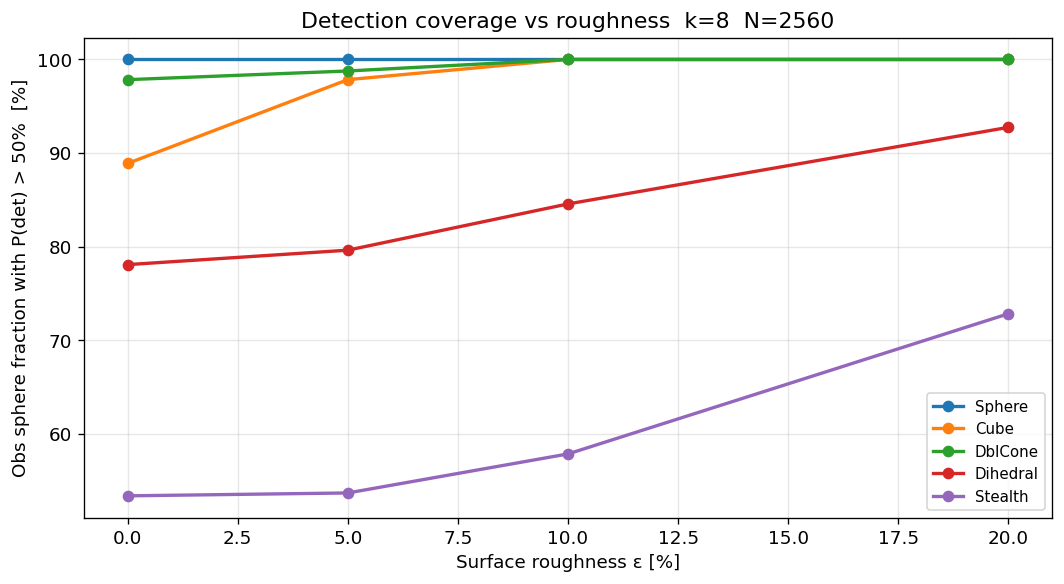

In [5]:
f_idx = 2
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['C0','C1','C2','C3','C4']

for tgt, color in zip(TARGETS, colors):
    frac_detected = []
    for r_idx in range(len(ROUGHNESS_FRACS)):
        d = load_group(tgt['id'], r_idx, f_idx)
        if d is None:
            frac_detected.append(np.nan)
        else:
            # Fraction of obs sphere where P(det) > 50%
            frac = (d['p_detect'] > 0.5).mean()
            frac_detected.append(frac * 100)
    ax.plot([e*100 for e in ROUGHNESS_FRACS], frac_detected,
            'o-', color=color, lw=2, label=tgt['name'])

ax.set_xlabel('Surface roughness ε [%]')
ax.set_ylabel('Obs sphere fraction with P(det) > 50%  [%]')
ax.set_title(f'Detection coverage vs roughness  k={WAVENUMBERS[f_idx]:.0f}  N={N_PANELS}')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_stage4_3d_roughness_coverage.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Frequency sweep — stealth detection coverage vs k

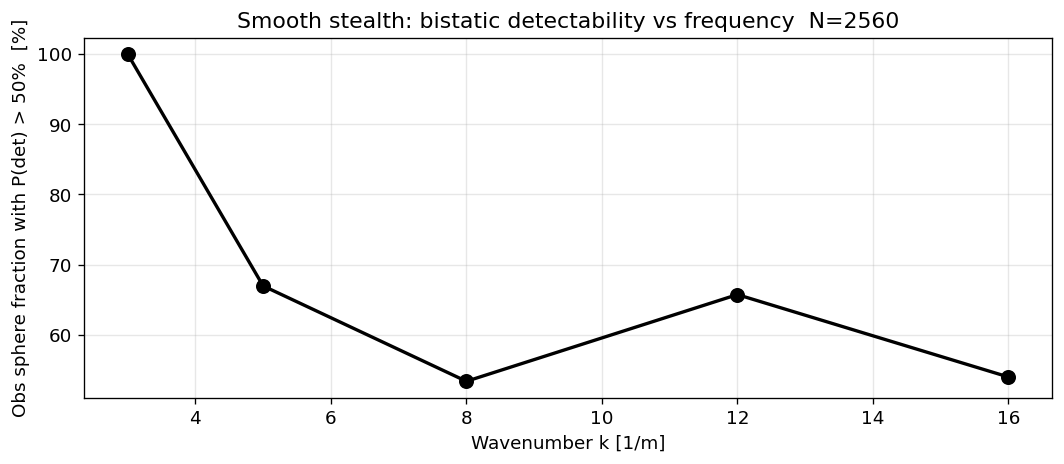

  k=3: 100.0% of obs sphere detectable
  k=5: 67.0% of obs sphere detectable
  k=8: 53.4% of obs sphere detectable
  k=12: 65.7% of obs sphere detectable
  k=16: 54.0% of obs sphere detectable


In [6]:
r_idx = 0   # smooth (ε=0)
t_idx = 4   # stealth
fig, ax = plt.subplots(figsize=(9, 4))

coverages = []
for f_idx, k in enumerate(WAVENUMBERS):
    d = load_group(t_idx, r_idx, f_idx)
    if d is None:
        coverages.append(np.nan)
    else:
        frac = (d['p_detect'] > 0.5).mean() * 100
        coverages.append(frac)

ax.plot(WAVENUMBERS, coverages, 'ko-', lw=2, ms=8)
ax.set_xlabel('Wavenumber k [1/m]')
ax.set_ylabel('Obs sphere fraction with P(det) > 50%  [%]')
ax.set_title('Smooth stealth: bistatic detectability vs frequency  N=2560')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_stage4_3d_stealth_freq.png', dpi=120, bbox_inches='tight')
plt.show()

for k, cov in zip(WAVENUMBERS, coverages):
    print(f'  k={k:.0f}: {cov:.1f}% of obs sphere detectable')


## 6. Summary

Stage 4 (N=2560, 5,000 solves) gives the first complete P(detect) landscape.
Key findings from the 3D bistatic sphere:

- **Sphere**: roughly isotropic with Mie-resonance elevation structure.
- **Cube**: strong specular returns at face-normal directions (θ=90°, φ=0°/90°/180°/270°).
  High P(detect) at face-normal; low in between.
- **Double cone**: retroreflection near tip elevation angles.
- **Dihedral corner**: high P(detect) in the retroreflective quadrant.
- **Stealth**: suppressed near nose-on backscatter but elevated flanking detection —
  the 3D "stealth paradox" matches the 2D Stage 7 finding: shaping redirects energy
  to ±90° lateral angles where P(detect) remains high.

Stage 5 (resolution audit at N=5120) will quantify how much the N=2560 results
agree with the higher-resolution solver.
